In [1]:
from pathlib import Path

import pandas as pd
from tqdm import tqdm

from utils import (
    asymmetric_late_prediction_weights,
    time_to_event_training_weights,
    train_models_for_target,
)

In [2]:
DATA_DIR = Path("output")
CSV_PATTERN = "dataset_winsize*.csv"

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
DEVICE = "cuda:0"
EARLY_PREDICTION_COST = 1.0
LATE_PREDICTION_COST = 5.0


def regression_metric_weight_fn(y_true, y_pred):
    return asymmetric_late_prediction_weights(
        y_true,
        y_pred,
        early_prediction_cost=EARLY_PREDICTION_COST,
        late_prediction_cost=LATE_PREDICTION_COST,
    )


TARGETS = {
    "label_time_to_event_seconds": "regression",
    "label_from_zone": "classification",
    "label_to_zone": "classification",
}

DROP_COLUMNS = [
    "fold_id",
    "label_is_auto",
    "label_time_to_event_seconds",
    "label_from_zone",
    "label_to_zone",
]

REGRESSION_SUMMARY_FILENAME = "regression_summary_XGBoost.csv"
CLASSIFICATION_SUMMARY_FILENAME = "classification_summary_XGBoost.csv"

In [3]:
csv_files = sorted(
    DATA_DIR.glob(CSV_PATTERN),
    key=lambda p: float(p.stem.split("winsize", 1)[1].removesuffix("h")),
)
csv_file_path = csv_files[4]

csv_file_path, csv_files

(PosixPath('output/dataset_winsize3h.csv'),
 [PosixPath('output/dataset_winsize0.25h.csv'),
  PosixPath('output/dataset_winsize0.5h.csv'),
  PosixPath('output/dataset_winsize1h.csv'),
  PosixPath('output/dataset_winsize2h.csv'),
  PosixPath('output/dataset_winsize3h.csv'),
  PosixPath('output/dataset_winsize4h.csv'),
  PosixPath('output/dataset_winsize5h.csv'),
  PosixPath('output/dataset_winsize6h.csv'),
  PosixPath('output/dataset_winsize7h.csv'),
  PosixPath('output/dataset_winsize8h.csv'),
  PosixPath('output/dataset_winsize9h.csv'),
  PosixPath('output/dataset_winsize10h.csv'),
  PosixPath('output/dataset_winsize11h.csv'),
  PosixPath('output/dataset_winsize12h.csv')])

In [4]:
df = pd.read_csv(csv_file_path)

print(f"\nReading {csv_file_path}")


Reading output/dataset_winsize3h.csv


# Regression task

## search xgboost parameters for the best model

In [ ]:
import os

import numpy as np
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

grid_n_jobs = 1 if DEVICE.startswith("cuda") else -1


def neg_mean_absolute_error_scorer(estimator, X, y_true):
    """Compute MAE after explicitly moving device arrays to CPU."""
    y_pred = estimator.predict(X)
    if hasattr(y_true, "get"):
        y_true = y_true.get()
    if hasattr(y_pred, "get"):
        y_pred = y_pred.get()
    return -float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    device=DEVICE,
    n_jobs=1,
    random_state=42,
)

param_grid = {
    "n_estimators": [30, 100, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [0.1, 1, 10],
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=neg_mean_absolute_error_scorer,
    cv=5,
    n_jobs=grid_n_jobs,
    verbose=2,
)

In [6]:
regression_target = [k for k, v in TARGETS.items() if v == "regression"][0]
train_df = df[df["fold_id"] != -1].copy()

X_train = train_df.drop(columns=DROP_COLUMNS, errors="ignore")
X_train = X_train.select_dtypes(include=["number", "bool"])
y_train = train_df[regression_target]

target_is_present = y_train.notna()
X_train = X_train.loc[target_is_present]
y_train = y_train.loc[target_is_present]

if DEVICE.startswith("cuda"):
    import cupy as cp

    # Keep cross-validation training and prediction data on the same GPU.
    X_train = cp.asarray(X_train.to_numpy(dtype="float32"))
    y_train = cp.asarray(y_train.to_numpy(dtype="float32"))

print(f"XGBoost device: {DEVICE}; GridSearchCV n_jobs: {grid_n_jobs}")
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best cross-validation MAE:", -grid.best_score_)

XGBoost device: cuda:0; GridSearchCV n_jobs: 1
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, n_estimators=30, reg_lambda=0.1, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, n_estimators=30, reg_lambda=0.1, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, n_estimators=30, reg_lambda=0.1, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, n_estimators=30, reg_lambda=0.1, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, n_estimators=30, reg_lambda=0.1, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, n_estimators=30, reg_lambda=0.1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, n_estimators=30, reg_lambda=0.1, subsam

In [7]:
regression_results = pd.DataFrame(grid.cv_results_)
regression_results["mean_test_mae"] = -regression_results["mean_test_score"]
regression_results["std_test_mae"] = regression_results["std_test_score"]
regression_results = regression_results.sort_values(
    ["mean_test_mae", "mean_fit_time"],
    ascending=[True, True],
).reset_index(drop=True)

regression_summary_path = OUTPUT_DIR / REGRESSION_SUMMARY_FILENAME
regression_results.to_csv(regression_summary_path, index=False)

print(f"Saved {len(regression_results)} results to {regression_summary_path}")
regression_results.head(10)

Saved 324 results to model_outputs/regression_summary_XGBoost.csv


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_n_estimators,param_reg_lambda,param_subsample,...,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,mean_test_mae,std_test_mae
0,0.374998,0.015342,0.003193,0.000061,1.0,0.05,7,100,10.0,1.0,...,-4173.050781,-4207.874512,-5362.253906,-4633.187012,-4761.419922,-4627.557227,433.691092,1,4627.557227,433.691092
1,0.402963,0.012131,0.003232,0.000335,1.0,0.05,7,100,10.0,0.8,...,-4242.742188,-4216.668945,-5423.841309,-4641.322754,-4721.523438,-4649.219727,437.642080,2,4649.219727,437.642080
2,0.354517,0.012002,0.003320,0.000164,0.8,0.05,7,100,10.0,1.0,...,-4244.305664,-4217.463379,-5429.002930,-4660.035645,-4708.283203,-4651.818164,438.634815,3,4651.818164,438.634815
3,0.115869,0.003515,0.001479,0.000175,1.0,0.10,7,30,10.0,1.0,...,-4180.840332,-4240.993652,-5441.169434,-4648.999512,-4808.555176,-4664.111621,455.519728,4,4664.111621,455.519728
4,0.367713,0.013349,0.002973,0.000522,0.8,0.05,7,100,10.0,0.8,...,-4246.783691,-4231.786621,-5424.942383,-4665.319336,-4780.716309,-4669.909668,436.660275,5,4669.909668,436.660275
5,0.111114,0.003404,0.001614,0.000342,0.8,0.10,7,30,10.0,1.0,...,-4177.556152,-4280.328613,-5408.837402,-4664.790039,-4834.896484,-4673.281738,439.861247,6,4673.281738,439.861247
6,0.357572,0.010832,0.002874,0.000582,1.0,0.03,7,100,10.0,1.0,...,-4179.420898,-4257.760742,-5426.634766,-4667.716797,-4851.107422,-4676.528125,450.709942,7,4676.528125,450.709942
7,0.380899,0.009189,0.002990,0.000322,0.8,0.05,7,100,1.0,1.0,...,-4297.772461,-4223.704102,-5409.318848,-4641.098145,-4871.767090,-4688.732129,429.910814,8,4688.732129,429.910814
8,0.332607,0.010141,0.003138,0.000435,0.8,0.03,7,100,10.0,1.0,...,-4166.239746,-4291.814941,-5436.167480,-4705.791992,-4870.628906,-4694.128613,452.201949,9,4694.128613,452.201949
9,0.379666,0.011774,0.002750,0.000197,1.0,0.03,7,100,10.0,0.8,...,-4242.205566,-4245.840820,-5438.546387,-4690.574707,-4864.502930,-4696.334082,444.605426,10,4696.334082,444.605426


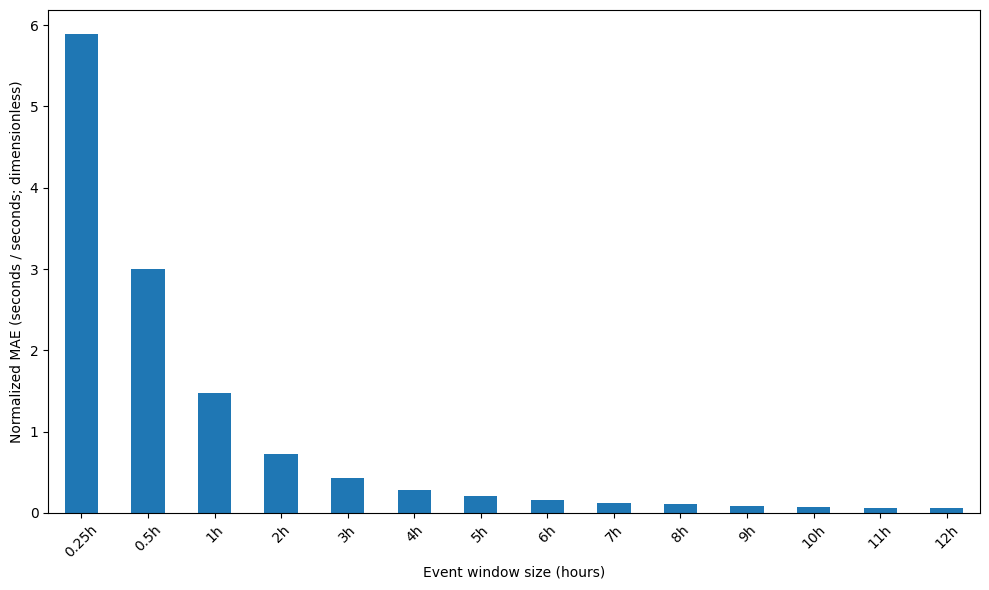

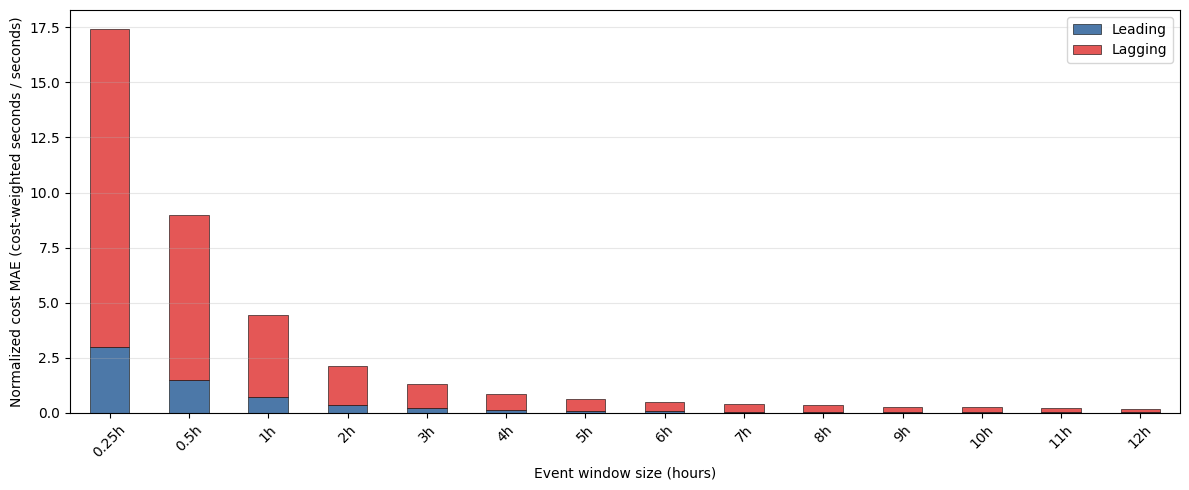

,dataset,winsize,winsize_hours,mae,mae_norm,leading_norm_cost_mae,lagging_norm_cost_mae,normalized_cost_mae,lagging_prediction_rate
0,dataset_winsize0.25h,0.25h,0.25,5302.259326,5.891399,3.010644,14.403775,17.414420,0.633250
1,dataset_winsize0.5h,0.5h,0.50,5405.381335,3.002990,1.511751,7.456193,8.967944,0.642439
2,dataset_winsize1h,1h,1.00,5299.071969,1.471964,0.733638,3.691632,4.425270,0.634921
3,dataset_winsize2h,2h,2.00,5196.683236,0.721762,0.366544,1.776086,2.142630,0.643275
4,dataset_winsize3h,3h,3.00,4688.175328,0.434090,0.211344,1.113732,1.325076,0.650794
5,dataset_winsize4h,4h,4.00,4084.955897,0.283677,0.137936,0.728710,0.866645,0.664160
6,dataset_winsize5h,5h,5.00,3759.930171,0.208885,0.097102,0.558916,0.656018,0.659148
7,dataset_winsize6h,6h,6.00,3439.604816,0.159241,0.072057,0.435921,0.507978,0.659983
8,dataset_winsize7h,7h,7.00,3233.578388,0.128317,0.056589,0.358637,0.415226,0.664996
9,dataset_winsize8h,8h,8.00,3029.502916,0.105191,0.045365,0.299131,0.344496,0.628237


In [9]:
import matplotlib.pyplot as plt
from sklearn.base import clone

xgboost_window_rows = []

for dataset_path in csv_files:
    dataset_df = pd.read_csv(dataset_path)
    train_df = dataset_df[dataset_df["fold_id"] != -1].copy()
    test_df = dataset_df[dataset_df["fold_id"] == -1].copy()

    X_train_window = train_df.drop(columns=DROP_COLUMNS, errors="ignore")
    X_train_window = X_train_window.select_dtypes(include=["number", "bool"])
    y_train_window = train_df[regression_target]
    train_mask = y_train_window.notna()
    X_train_window = X_train_window.loc[train_mask]
    y_train_window = y_train_window.loc[train_mask]

    X_test_window = test_df.drop(columns=DROP_COLUMNS, errors="ignore")
    X_test_window = X_test_window.select_dtypes(include=["number", "bool"])
    y_test_window = test_df[regression_target]
    test_mask = y_test_window.notna()
    X_test_window = X_test_window.loc[test_mask]
    y_test_window = y_test_window.loc[test_mask].astype(float)

    if DEVICE.startswith("cuda"):
        X_train_fit = cp.asarray(X_train_window.to_numpy(dtype="float32"))
        y_train_fit = cp.asarray(y_train_window.to_numpy(dtype="float32"))
        X_test_fit = cp.asarray(X_test_window.to_numpy(dtype="float32"))
    else:
        X_train_fit = X_train_window
        y_train_fit = y_train_window
        X_test_fit = X_test_window

    best_model = clone(grid.best_estimator_)
    best_model.fit(X_train_fit, y_train_fit)
    y_pred = best_model.predict(X_test_fit)
    if hasattr(y_pred, "get"):
        y_pred = y_pred.get()
    y_pred = pd.Series(y_pred, index=y_test_window.index, dtype=float)

    error = y_pred - y_test_window
    absolute_error = error.abs()
    lagging_mask = error > 0
    leading_cost_mae = np.where(
        lagging_mask,
        0.0,
        EARLY_PREDICTION_COST * absolute_error,
    ).mean()
    lagging_cost_mae = np.where(
        lagging_mask,
        LATE_PREDICTION_COST * absolute_error,
        0.0,
    ).mean()

    winsize = dataset_path.stem.split("winsize", 1)[1]
    winsize_hours = float(winsize.removesuffix("h"))
    winsize_seconds = winsize_hours * 3600
    xgboost_window_rows.append(
        {
            "dataset": dataset_path.stem,
            "winsize": winsize,
            "winsize_hours": winsize_hours,
            "mae": absolute_error.mean(),
            "mae_norm": absolute_error.mean() / winsize_seconds,
            "leading_norm_cost_mae": leading_cost_mae / winsize_seconds,
            "lagging_norm_cost_mae": lagging_cost_mae / winsize_seconds,
            "normalized_cost_mae": (leading_cost_mae + lagging_cost_mae)
            / winsize_seconds,
            "lagging_prediction_rate": lagging_mask.mean(),
        }
    )

xgboost_window_df = pd.DataFrame(xgboost_window_rows).sort_values("winsize_hours")
xgboost_window_df.to_csv(
    OUTPUT_DIR / "xgboost_regression_window_metrics.csv",
    index=False,
)

ax = xgboost_window_df.plot(
    x="winsize",
    y="mae_norm",
    kind="bar",
    figsize=(10, 6),
    legend=False,
)
ax.set_xlabel("Event window size (hours)")
ax.set_ylabel("Normalized MAE (seconds / seconds; dimensionless)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(
    Path("output") / "xgboost_regression_mae_norm_bar.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

ax = xgboost_window_df.set_index("winsize")[
    ["leading_norm_cost_mae", "lagging_norm_cost_mae"]
].plot(
    kind="bar",
    stacked=True,
    color=["#4C78A8", "#E45756"],
    edgecolor="black",
    linewidth=0.4,
    figsize=(12, 5),
)
ax.set_xlabel("Event window size (hours)")
ax.set_ylabel("Normalized cost MAE (cost-weighted seconds / seconds)")
ax.legend(["Leading", "Lagging"], loc="upper right")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(
    Path("output") / "xgboost_regression_cost_mae_lead_lag_breakdown.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

xgboost_window_df